# 07 - Phase 2 Environment

This notebook validates the dynamic Door + Key Maze before training. It checks the observation shape, reset-varying object placement, mandatory-door constraint, reward modes, BFS oracle, and random-agent behaviour.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.env import DoorKeyMazeEnv, DOOR_LOCKED, KEY

plt.rcParams["figure.figsize"] = (5, 5)

## Build The Phase 2 Maze

The environment keeps the Phase 1 parameter style: `level`, `size`, and `difficulty` are still first-class controls.

In [2]:
MAZE_SEED = 42
LEVEL = "small"
DIFFICULTY = "hard"

env = DoorKeyMazeEnv(level=LEVEL, difficulty=DIFFICULTY, seed=MAZE_SEED, reward_type="sparse")
obs, info = env.reset()

print("size:", env.size)
print("observation shape:", obs.shape)
print("key position:", info["key_pos"])
print("door position:", info["door_pos"])
print("layout id:", info["layout_id"])
print("optimal path length:", info["optimal_path_len"])
print("max steps:", env.max_steps)
info

size: 10
observation shape: (102,)
key position: (9, 0)
door position: (3, 5)
layout id: 0
optimal path length: 38
max steps: 400


{'agent_pos': (0, 0),
 'goal_pos': (9, 9),
 'key_pos': (9, 0),
 'door_pos': (3, 5),
 'has_key': 0,
 'door_open': 0,
 'picked_up_key': 0,
 'opened_door': 0,
 'picked_key_now': False,
 'opened_door_now': False,
 'wall_collisions': 0,
 'steps_to_key': None,
 'steps_to_door': None,
 'steps_taken': 0,
 'optimal_path_len': 38,
 'hit_wall': False,
 'action_name': 'N/A',
 'maze_size': 10,
 'level': 'small',
 'difficulty': 'hard',
 'reward_type': 'sparse',
 'dynamic_objects': True,
 'layout_id': 0}

## Confirm Dynamic Key/Door Layouts

The wall topology, door chokepoint, key location, and optimal path can change between episodes. Each sampled layout is still validated so the door is mandatory.

In [3]:
seen_layouts = []
for _ in range(10):
    _, info = env.reset()
    seen_layouts.append((info["layout_id"], info["key_pos"], info["door_pos"], info["optimal_path_len"]))

for row in sorted(set(seen_layouts)):
    print("layout=", row[0], "key=", row[1], "door=", row[2], "optimal=", row[3])

assert len(set(seen_layouts)) > 1, "Dynamic mode should sample more than one key/door layout."


layout= 0 key= (9, 0) door= (3, 5) optimal= 38
layout= 1 key= (9, 0) door= (2, 3) optimal= 38
layout= 2 key= (9, 4) door= (2, 1) optimal= 48
layout= 3 key= (6, 2) door= (1, 2) optimal= 48


## Visualise The Current Layout

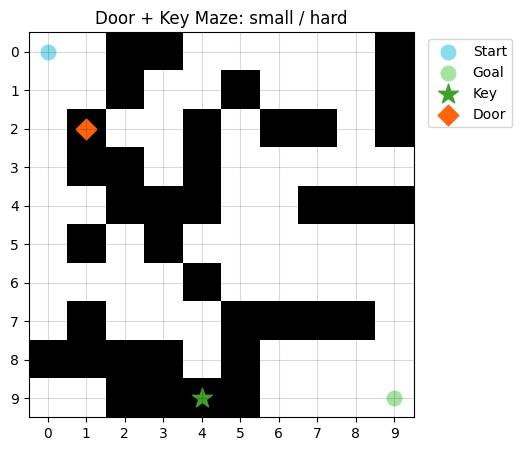

In [4]:
def plot_door_key_layout(env):
    grid = env.base_maze.copy()
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(grid, cmap="gray_r", vmin=0, vmax=1)
    ax.scatter([env.start_pos[1]], [env.start_pos[0]], c="#89dceb", s=110, label="Start")
    ax.scatter([env.goal_pos[1]], [env.goal_pos[0]], c="#a6e3a1", s=110, label="Goal")
    ax.scatter([env.key_pos[1]], [env.key_pos[0]], c="#40a02b", marker="*", s=220, label="Key")
    ax.scatter([env.door_pos[1]], [env.door_pos[0]], c="#fe640b", marker="D", s=110, label="Door")
    ax.set_xticks(range(env.size)); ax.set_yticks(range(env.size))
    ax.grid(color="black", alpha=0.15)
    ax.set_title(f"Door + Key Maze: {env.level or env.size} / {env.difficulty}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.show()

plot_door_key_layout(env)

## Hard Constraint: No Door Bypass

In [5]:
blocked = env.base_maze.copy()
blocked[env.door_pos] = 1
bypass_distance = env._bfs_dist_on(blocked, env.start_pos, env.goal_pos)

assert bypass_distance == -1, "Invalid maze: start can reach goal without the door."
print("PASS: treating the door as a wall removes every start-to-goal path.")

PASS: treating the door as a wall removes every start-to-goal path.


## Validate Difficulty Parameters

In [6]:
for difficulty in ["easy", "medium", "hard"]:
    e = DoorKeyMazeEnv(level="small", difficulty=difficulty, seed=42)
    print(difficulty, "key=", e.key_pos, "door=", e.door_pos, "optimal=", e.optimal_path_length())
    assert e.optimal_path_length() > 0

easy key= (8, 0) door= (2, 4) optimal= 32
medium key= (9, 6) door= (2, 5) optimal= 52
hard key= (9, 0) door= (3, 5) optimal= 38


## Reward Mode Smoke Tests

In [7]:
for reward_type in ["sparse", "subgoal", "potential"]:
    e = DoorKeyMazeEnv(level="small", difficulty="medium", seed=42, reward_type=reward_type)
    obs, info = e.reset()
    obs, reward, terminated, truncated, info = e.step(e.action_space.sample())
    print(reward_type, "reward=", round(float(reward), 4), "obs=", obs.shape)
    assert obs.shape == (e.size * e.size + 2,)

sparse reward= -0.5 obs= (102,)
subgoal reward= -0.5 obs= (102,)
potential reward= -0.33 obs= (102,)


## Random Agent Baseline

In [8]:
def run_random_agent(env, episodes=100, seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for ep in range(episodes):
        env.reset()
        total = 0.0
        done = False
        while not done:
            action = int(rng.integers(env.action_space.n))
            _, reward, terminated, truncated, info = env.step(action)
            total += reward
            done = terminated or truncated
        rows.append((total, int(terminated), info["picked_up_key"], info["opened_door"], env.steps_taken))
    return np.array(rows, dtype=float)

random_stats = run_random_agent(DoorKeyMazeEnv(level="small", difficulty="medium", seed=42, reward_type="subgoal"), episodes=100)
print("success rate:", random_stats[:, 1].mean())
print("key pickup rate:", random_stats[:, 2].mean())
print("door opening rate:", random_stats[:, 3].mean())
print("mean steps:", random_stats[:, 4].mean())

success rate: 0.0
key pickup rate: 0.38
door opening rate: 0.15
mean steps: 400.0
